# Business question: How can movie sales/success be predicted based on the language of reviews, the marketing aspects, and movie production elements?

# Suggested sub questions:
Language of Reviews: Can the sentiment and semantic themes (extracted via Transformer embeddings) from expert and user reviews accurately predict the box office tier of a movie?

Marketing Aspects: To what extent do the number of theaters and "opening weekend" performance correlate with long-term international box office success?

Production Elements: Which production features (Genre, Runtime, Rating, and Studio) are the strongest predictors of a movie’s financial success?

Model Performance: Which model (Baseline, Random Forest, or Neural Network) provides the highest accuracy in predicting movie success using these combined features?

In [425]:
# Uploading the libraries that we need

import pandas as pd # for data manipulaion
import seaborn as sns # for visualization
import matplotlib.pyplot as plt # for visualization
import numpy as np # for computation
import re # to work with regular expressions
from sklearn.impute import KNNImputer # to be used for KNN (runtime imputation)


In [426]:
# Importing the datasets that we need to work with.

df_sales = pd.read_excel("../Metacritic dataset/sales.xlsx")
df_meta = pd.read_excel("../Metacritic dataset/metaClean43Brightspace.xlsx")
df_user = pd.read_excel("../Metacritic dataset/UserReviews.xlsx")
df_expert = pd.read_excel("../Metacritic dataset/ExpertReviews.xlsx")

expert_features = pd.read_csv("../data/processed/expert_features_with_embeddings.csv")
user_features   = pd.read_csv("../data/processed/user_features_with_embeddings.csv")


In [427]:
# Check our data frames and data types.

df_sales.info()
df_meta.info()
df_user.info()
df_expert.info()

expert_features.info()
user_features.info()

# df_sales.tale(10) # just to check 
# df_sales.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30604 non-null  object 
 3   genre                     28908 non-null  object 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   Unnamed: 8                0 non-null      float64
 9   opening_weekend           10929 non-null  float64
 10  theatre_count             10963 non-null  float64
 11  avg run per theatre       10952 non-null  float64
 12  runtime                   24559 non-null  float64
 13  keywords                  12517 non-null  object 
 14  creati

In [428]:
df_sales.head(3)

,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url
0,2000,January 1st,Bakha Satang,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2001,January 12th,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,NaN,5486209.0,2433.0,3.1,NaN,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,2000,January 28th,Santitos,NaN,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos


In [429]:
df_sales.shape

(30612, 16)

In [430]:
df_sales.dtypes

year                          int64
release_date                 object
title                        object
genre                        object
international_box_office    float64
domestic_box_office         float64
worldwide_box_office        float64
production_budget           float64
Unnamed: 8                  float64
opening_weekend             float64
theatre_count               float64
avg run per theatre         float64
runtime                     float64
keywords                     object
creative_type                object
url                          object
dtype: object

In [431]:
df_sales.describe()

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,2.157500e+04,1.188400e+04,2.157500e+04,4.480000e+03,0.0,1.092900e+04,10963.000000,10952.000000,24559.000000
mean,2014.542108,1.586202e+07,1.735331e+07,2.524796e+07,3.642238e+07,NaN,5.488562e+06,723.147040,4.124562,101.502993
std,5.525085,6.659680e+07,5.050972e+07,1.009796e+08,4.644049e+07,NaN,1.633207e+07,1246.401636,3.423855,27.194334
min,2000.000000,2.000000e+00,2.000000e+01,2.000000e+00,1.100000e+03,NaN,1.100000e+01,1.000000,0.000000,11.000000
25%,2012.000000,2.637500e+04,2.986550e+04,3.422900e+04,6.500000e+06,NaN,7.352000e+03,2.000000,2.000000,89.000000
50%,2016.000000,3.348470e+05,2.587510e+05,4.753220e+05,2.000000e+07,NaN,4.087500e+04,8.000000,3.400000,97.000000
75%,2019.000000,4.282312e+06,7.667212e+06,6.302152e+06,4.500000e+07,NaN,2.150979e+06,969.500000,5.400000,110.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,NaN,3.571150e+08,4725.000000,88.400000,2020.000000


In [432]:
 df_sales.isna().sum()

year                            0
release_date                    0
title                           8
genre                        1704
international_box_office     9037
domestic_box_office         18728
worldwide_box_office         9037
production_budget           26132
Unnamed: 8                  30612
opening_weekend             19683
theatre_count               19649
avg run per theatre         19660
runtime                      6053
keywords                    18095
creative_type                3945
url                             0
dtype: int64

In [433]:
df_sales.duplicated().sum()

0

In [434]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'Unnamed: 8', 'opening_weekend', 'theatre_count', 'avg run per theatre',
       'runtime', 'keywords', 'creative_type', 'url'],
      dtype='object')

Cleaning data:

In [435]:
# Function to clean movie titles in Sales and Meta tables (since sales table doesn't use the same URLs and both dataframes have title columns in them). Code by Muayyad 
def clean_title(text):
    if pd.isna(text):
        return ""
    # Convert to string, lowercase, and remove extra spaces
    return str(text).lower().strip()

# Apply cleaning to both dataframes
df_sales['title_clean'] = df_sales['title'].apply(clean_title)
df_meta['title_clean'] = df_meta['title'].apply(clean_title)

In [436]:
# cleaning meta and sales tables and datatypes. Code by Muayyad 

# function to fix garbled names (used before in DB course)
def fix_names(name):
    if not isinstance(name, str) or name.lower() == 'nan':
        return "Unknown"
    
    # Dictionary of common garbled characters (used before in DB course)
    replacements = {
        'Ã©': 'é', 'Ãª': 'ê', 'Ã¨': 'è', 'Ã§': 'ç', 'Ã ': 'à', 'Ã¡': 'á', 
        'Ã±': 'ñ', 'Ã¶': 'ö', 'Ã¼': 'ü', 'ã³': 'ó', 'Ã°': 'ð', 'Ãº': 'ú'
    }
    
    for pattern, replacement in replacements.items():
        name = name.replace(pattern, replacement)
    
    # Clean extra spaces and make it "Title Case"
    return " ".join(name.split()).title()



# Cleaning df_sales and the numerical columns:

# Drop entirely empty rows and columns
df_sales.dropna(how='all', axis=0, inplace=True) 
df_sales.dropna(how='all', axis=1, inplace=True) 

# Cleaning and fixing datatypes
sales_money_cols = [
    'international_box_office', 'domestic_box_office', 'worldwide_box_office', 
    'production_budget', 'opening_weekend'
]
for col in sales_money_cols:
    if col in df_sales.columns:
        df_sales[col] = df_sales[col].astype(str).str.replace(r'[$,]', '', regex=True)
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Fix other numerical columns
sales_numeric_cols = ['year', 'theatre_count', 'avg run per theatre', 'runtime']
for col in sales_numeric_cols:
    if col in df_sales.columns:
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Keep only the month in release_date (we might use this to create a season feature)
df_sales['release_date'] = df_sales['release_date'].str.split().str[0]

# Standardize the titles
df_sales['title'] = df_sales['title'].astype(str).str.strip()

# cleaning df_meta:

# Drop entirely empty rows and columns
df_meta.dropna(how='all', axis=0, inplace=True)
df_meta.dropna(how='all', axis=1, inplace=True)

# Clean rating column and remove '|'
df_meta['rating'] = df_meta['rating'].astype(str).str.replace('|', '', regex=False).str.strip()
df_meta['rating'] = df_meta['rating'].replace(['nan', ''], 'Unrated')

# Fix meta score and user score
df_meta['metascore'] = pd.to_numeric(df_meta['metascore'], errors='coerce').fillna(0)
df_meta['userscore'] = pd.to_numeric(df_meta['userscore'], errors='coerce').fillna(0)

# Clean runtime column
df_meta['runtime'] = df_meta['runtime'].astype(str).str.extract('(\d+)').astype(float).fillna(0)

# Fix (Director and Cast) names using the fix names function
df_meta['director'] = df_meta['director'].apply(fix_names)
df_meta['cast'] = df_meta['cast'].apply(fix_names)

# Fix release date and extract year (we'll use this to join movies based on title + year)
df_meta['RelDate'] = pd.to_datetime(df_meta['RelDate'], errors='coerce')
df_meta['year'] = df_meta['RelDate'].dt.year

# Fill missing summary text
df_meta['summary'] = df_meta['summary'].fillna("No summary available")

print("Both DataFrames cleaned according to their specific columns!")


Both DataFrames cleaned according to their specific columns!


In [437]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'opening_weekend', 'theatre_count', 'avg run per theatre', 'runtime',
       'keywords', 'creative_type', 'url', 'title_clean'],
      dtype='object')

Initial EDA for all sales data before the merge:

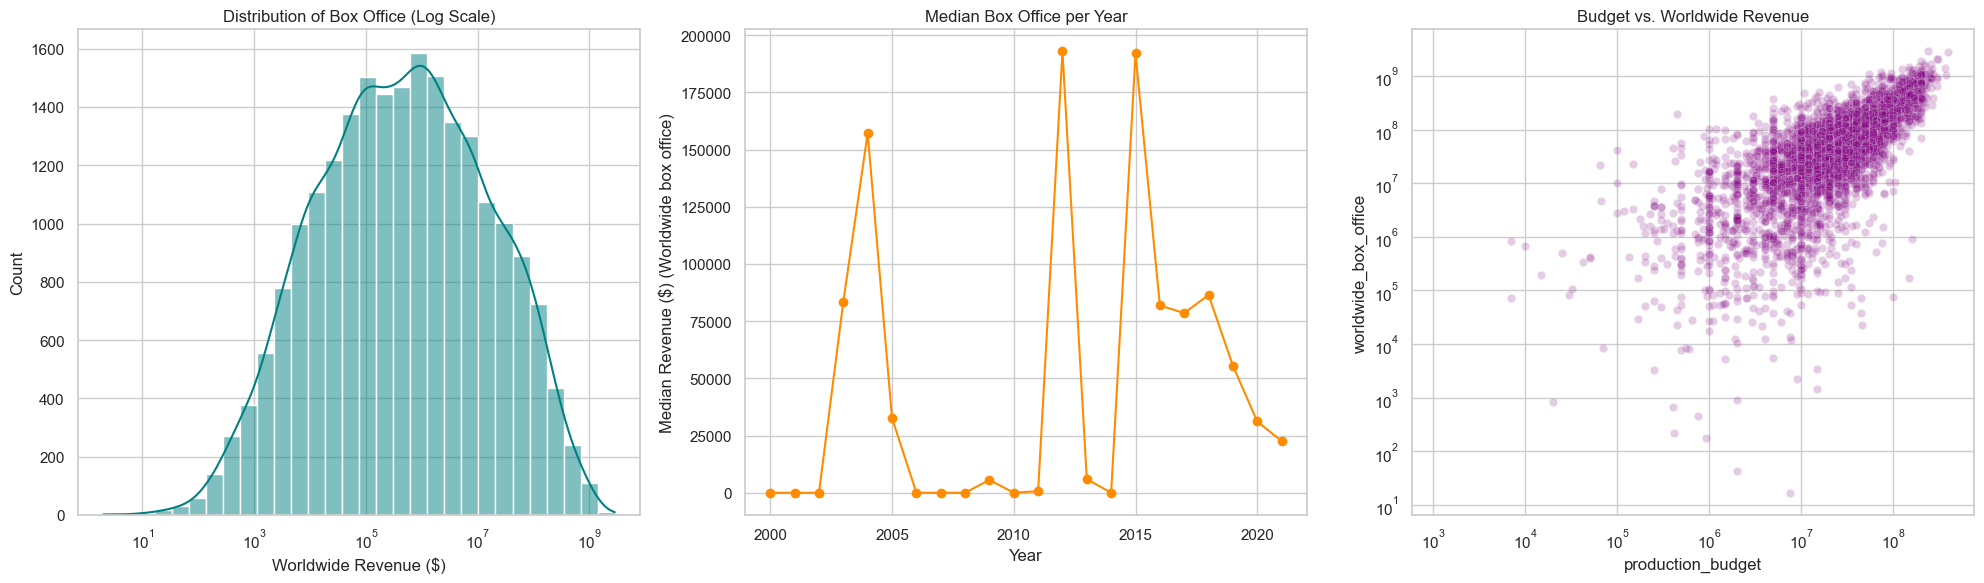

In [438]:
# Set the style for a professional look. Code by Muayyad 
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribution of Worldwide Box Office (Log Scale)
# This shows us the scale of the movies—most are small, few are blockbusters.
sns.histplot(df_sales[df_sales['worldwide_box_office'] > 0]['worldwide_box_office'], 
             bins=30, kde=True, ax=axes[0], log_scale=True, color='teal')
axes[0].set_title('Distribution of Box Office (Log Scale)')
axes[0].set_xlabel('Worldwide Revenue ($)')

# 2. Box Office Trends Over Time
# Shows how the industry has grown from the 30k records.
yearly_revenue = df_sales.groupby('year')['worldwide_box_office'].median()
axes[1].plot(yearly_revenue.index, yearly_revenue.values, marker='o', color='darkorange')
axes[1].set_title('Median Box Office per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Revenue ($) (Worldwide box office)')

# 3. Production Budget vs. Worldwide Box Office
# A scatter plot to see the correlation between spending and earning.
sns.scatterplot(data=df_sales[df_sales['production_budget'] > 0], 
                x='production_budget', y='worldwide_box_office', 
                alpha=0.2, ax=axes[2], color='purple')
axes[2].set_title('Budget vs. Worldwide Revenue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

1. The first graph shows that the market is dominated by a few successful movies (Blockbusters).
2. In the second graph we used the median to eleminate the effect of outliers, the decline around the year 2020 is consistent with the global impact of covid pandemic. (we'll investigate or drop the 0 values going further)
3. The last chart shows that there is a correlation between budget and world wide box office, but there is also a big variation, meaning that we need to look at other factors like "reviews" and "genres" to predict a blockbuster with our AI models.


C:\Users\mhama\AppData\Local\Temp\ipykernel_28900\770009325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
C:\Users\mhama\AppData\Local\Temp\ipykernel_28900\770009325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')


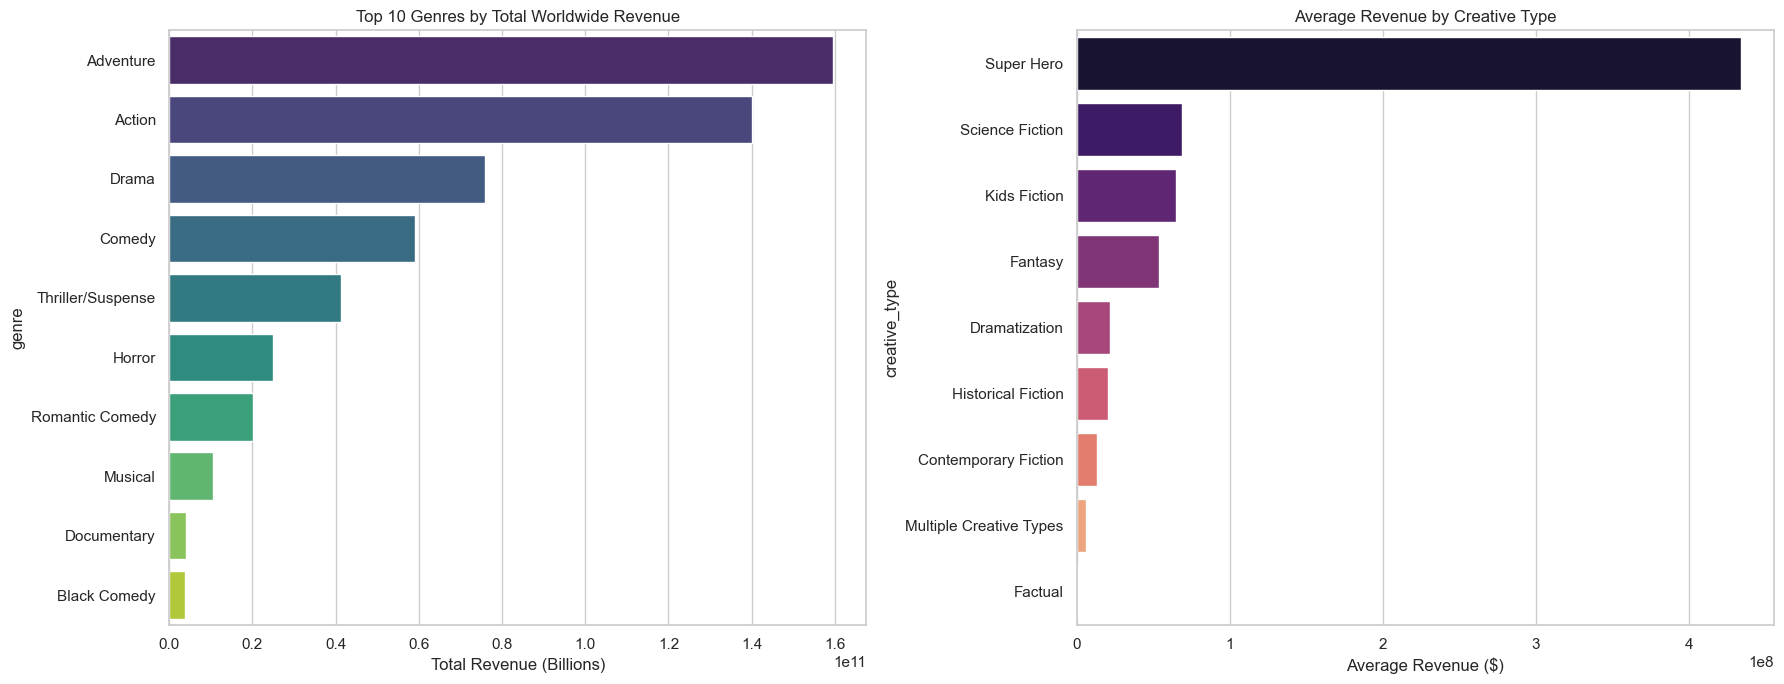

In [439]:
# Creating a figure with 2 subplots side-by-side for the two features that we see important. Code by Muayyad 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 Genres by total revenue
top_genres = df_sales.groupby('genre')['worldwide_box_office'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Total Worldwide Revenue')
axes[0].set_xlabel('Total Revenue (Billions)')

# Average revenue by creative type
creative_type = df_sales.groupby('creative_type')['worldwide_box_office'].mean().sort_values(ascending=False)
sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')
axes[1].set_title('Average Revenue by Creative Type')
axes[1].set_xlabel('Average Revenue ($)')

plt.tight_layout()
plt.show()

The categorical analysis reveals that Adventure and Action genres lead in total market volume, while the Super Hero creative type is the strongest individual indicator of high average revenue. These two key features will be very useful to detect blockbusters in the AI model.


Creating a master table that has all the required features to be used for AI modeling in a way that answers the business question:

In [440]:
# Data cleaning, and reviews aggregation, this will be used to add new features when making a master table. Code by Muayyad 

# Changing data types to numbers for some numerical columns in user and expert reviews dataframes:
df_user['idvscore'] = pd.to_numeric(df_user['idvscore'], errors='coerce')
df_expert['idvscore'] = pd.to_numeric(df_expert['idvscore'], errors='coerce')
df_user['thumbsUp'] = pd.to_numeric(df_user['thumbsUp'], errors='coerce')
df_user['thumbsTot'] = pd.to_numeric(df_user['thumbsTot'], errors='coerce')

# Aggregate one row per URL for user reviews:
user_agg = df_user.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count','thumbsUp': 'sum','thumbsTot': 'sum'}).reset_index()
user_agg.columns = ['url', 'user_idvscore_avg', 'user_rev_count','user_thumbsUp_tot', 'user_thumbsTot_tot']

# Create the Thumbs Down column using formula: thumbstot-thumbsup and dropping thumbs total (we keep only negative and positive)
user_agg['user_thumbsDown_tot'] = user_agg['user_thumbsTot_tot'] - user_agg['user_thumbsUp_tot']
user_agg = user_agg.drop(columns=['user_thumbsTot_tot'])

# Aggregate one row per URL for expert reviews:
expert_agg = df_expert.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count'}).reset_index()
expert_agg.columns = ['url', 'expert_score_avg', 'expert_rev_count']


In [441]:
# Creating the master table. Code by Muayyad 

# Standardize titles for the merge
df_sales['title_clean'] = df_sales['title'].str.lower().str.strip()
df_meta['title_clean'] = df_meta['title'].str.lower().str.strip()

# Merge Meta and Sales
df_master = pd.merge(
    df_meta, 
    df_sales, 
    on=['title_clean', 'year'], 
    how='inner', 
    suffixes=('', '_sales')
)

# Join the aggregated reviews tables
df_master = pd.merge(df_master, user_agg, on='url', how='left')
df_master = pd.merge(df_master, expert_agg, on='url', how='left')

# --------------------------------------------------
# MERGE EXPERT + USER EMBEDDINGS (ON URL)
# --------------------------------------------------
features_merged = pd.merge(
    expert_features,
    user_features,
    on='url',
    how='inner'
)

df_master = pd.merge(
    df_master,
    features_merged,
    on='url',
    how='left'
)


# Create unique Movie ID
df_master['movie_id'] = range(1, len(df_master) + 1)

# Handle missing review data by filling NaNs with 0 (this is useful for the AI model)
review_cols = [
    'user_idvscore_avg', 'user_rev_count', 'user_thumbsUp_tot', 
    'user_thumbsDown_tot', 'expert_score_avg', 'expert_rev_count'
]
df_master[review_cols] = df_master[review_cols].fillna(0)

# Final cleanup of duplicated columns
if 'title_sales' in df_master.columns:
    df_master.drop(columns=['title_sales'], inplace=True)

print(f"New Master Table created with {len(df_master)} movies.")
df_master[['title', 'year', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 'worldwide_box_office']].head()

New Master Table created with 8025 movies.


,title,year,user_thumbsUp_tot,user_thumbsDown_tot,worldwide_box_office
0,10 Cloverfield Lane,2016,390.0,535.0,108286422.0
1,10 Years,2012,1.0,1.0,987640.0
2,100 Bloody Acres,2013,0.0,0.0,0.0
3,"10,000 km",2015,0.0,0.0,20452.0
4,1001 Grams,2015,0.0,0.0,47019.0


In [442]:
# I want to add the movie ID back to the original dataframes as foreign key for better data integrity. Code by Muayyad 
# Create mapping with year and title
id_mapping = df_master[['title_clean', 'year', 'movie_id']].drop_duplicates()

# Add movie_id to df_sales
df_sales = pd.merge(df_sales, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to df_meta
df_meta = pd.merge(df_meta, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to the reviews datasets (using the 'url' which is unique)
# Create mapping with URL
url_mapping = df_master[['url', 'movie_id']].drop_duplicates()

df_user = pd.merge(df_user, url_mapping, on='url', how='left')
df_expert = pd.merge(df_expert, url_mapping, on='url', how='left')

df_sales.head(3) # check


,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url,title_clean,movie_id
0,2000,January,Bakha Satang,Drama,76576.0,0.0,76576.0,0.0,0.0,0.0,0.0,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...,bakha satang,NaN
1,2001,January,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,5486209.0,2433.0,3.1,0.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust,antitrust,531.0
2,2000,January,Santitos,NaN,0.0,378562.0,0.0,0.0,0.0,0.0,0.0,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos,santitos,5044.0


EDA and feature engineering for the master table:

In [443]:
# check data types and missing data. Code by Muayyad 
pd.concat([df_master.dtypes, df_master.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

,Data Type,Missing data count
url,object,0
title,object,0
studio,object,197
rating,object,0
runtime,float64,0
...,...,...
user_emb_764,float64,0
user_emb_765,float64,0
user_emb_766,float64,0
user_emb_767,float64,0


In [444]:
# Convert text columns we need to categorical.. Code by Muayyad 
df_master['rating'] = df_master['rating'].astype('category')
df_master['release_date'] = df_master['release_date'].astype('category') # because previously we only kept the year in this column
df_master['genre'] = df_master['genre'].astype('category')
df_master['studio'] = df_master['studio'].astype('category')
df_master['creative_type'] = df_master['creative_type'].astype('category')

# Convert floats to integers for columns that are "counts"
# better for the financial columns too since we have no decimal places
cols_to_int = ['production_budget', 'worldwide_box_office', 'theatre_count', 
               'user_thumbsUp_tot', 'user_thumbsDown_tot', 'metascore']

df_master[cols_to_int] = df_master[cols_to_int].astype('int64')

df_master.dtypes # check

url               object
title             object
studio          category
rating          category
runtime          float64
                  ...   
user_emb_764     float64
user_emb_765     float64
user_emb_766     float64
user_emb_767     float64
movie_id           int64
Length: 1577, dtype: object

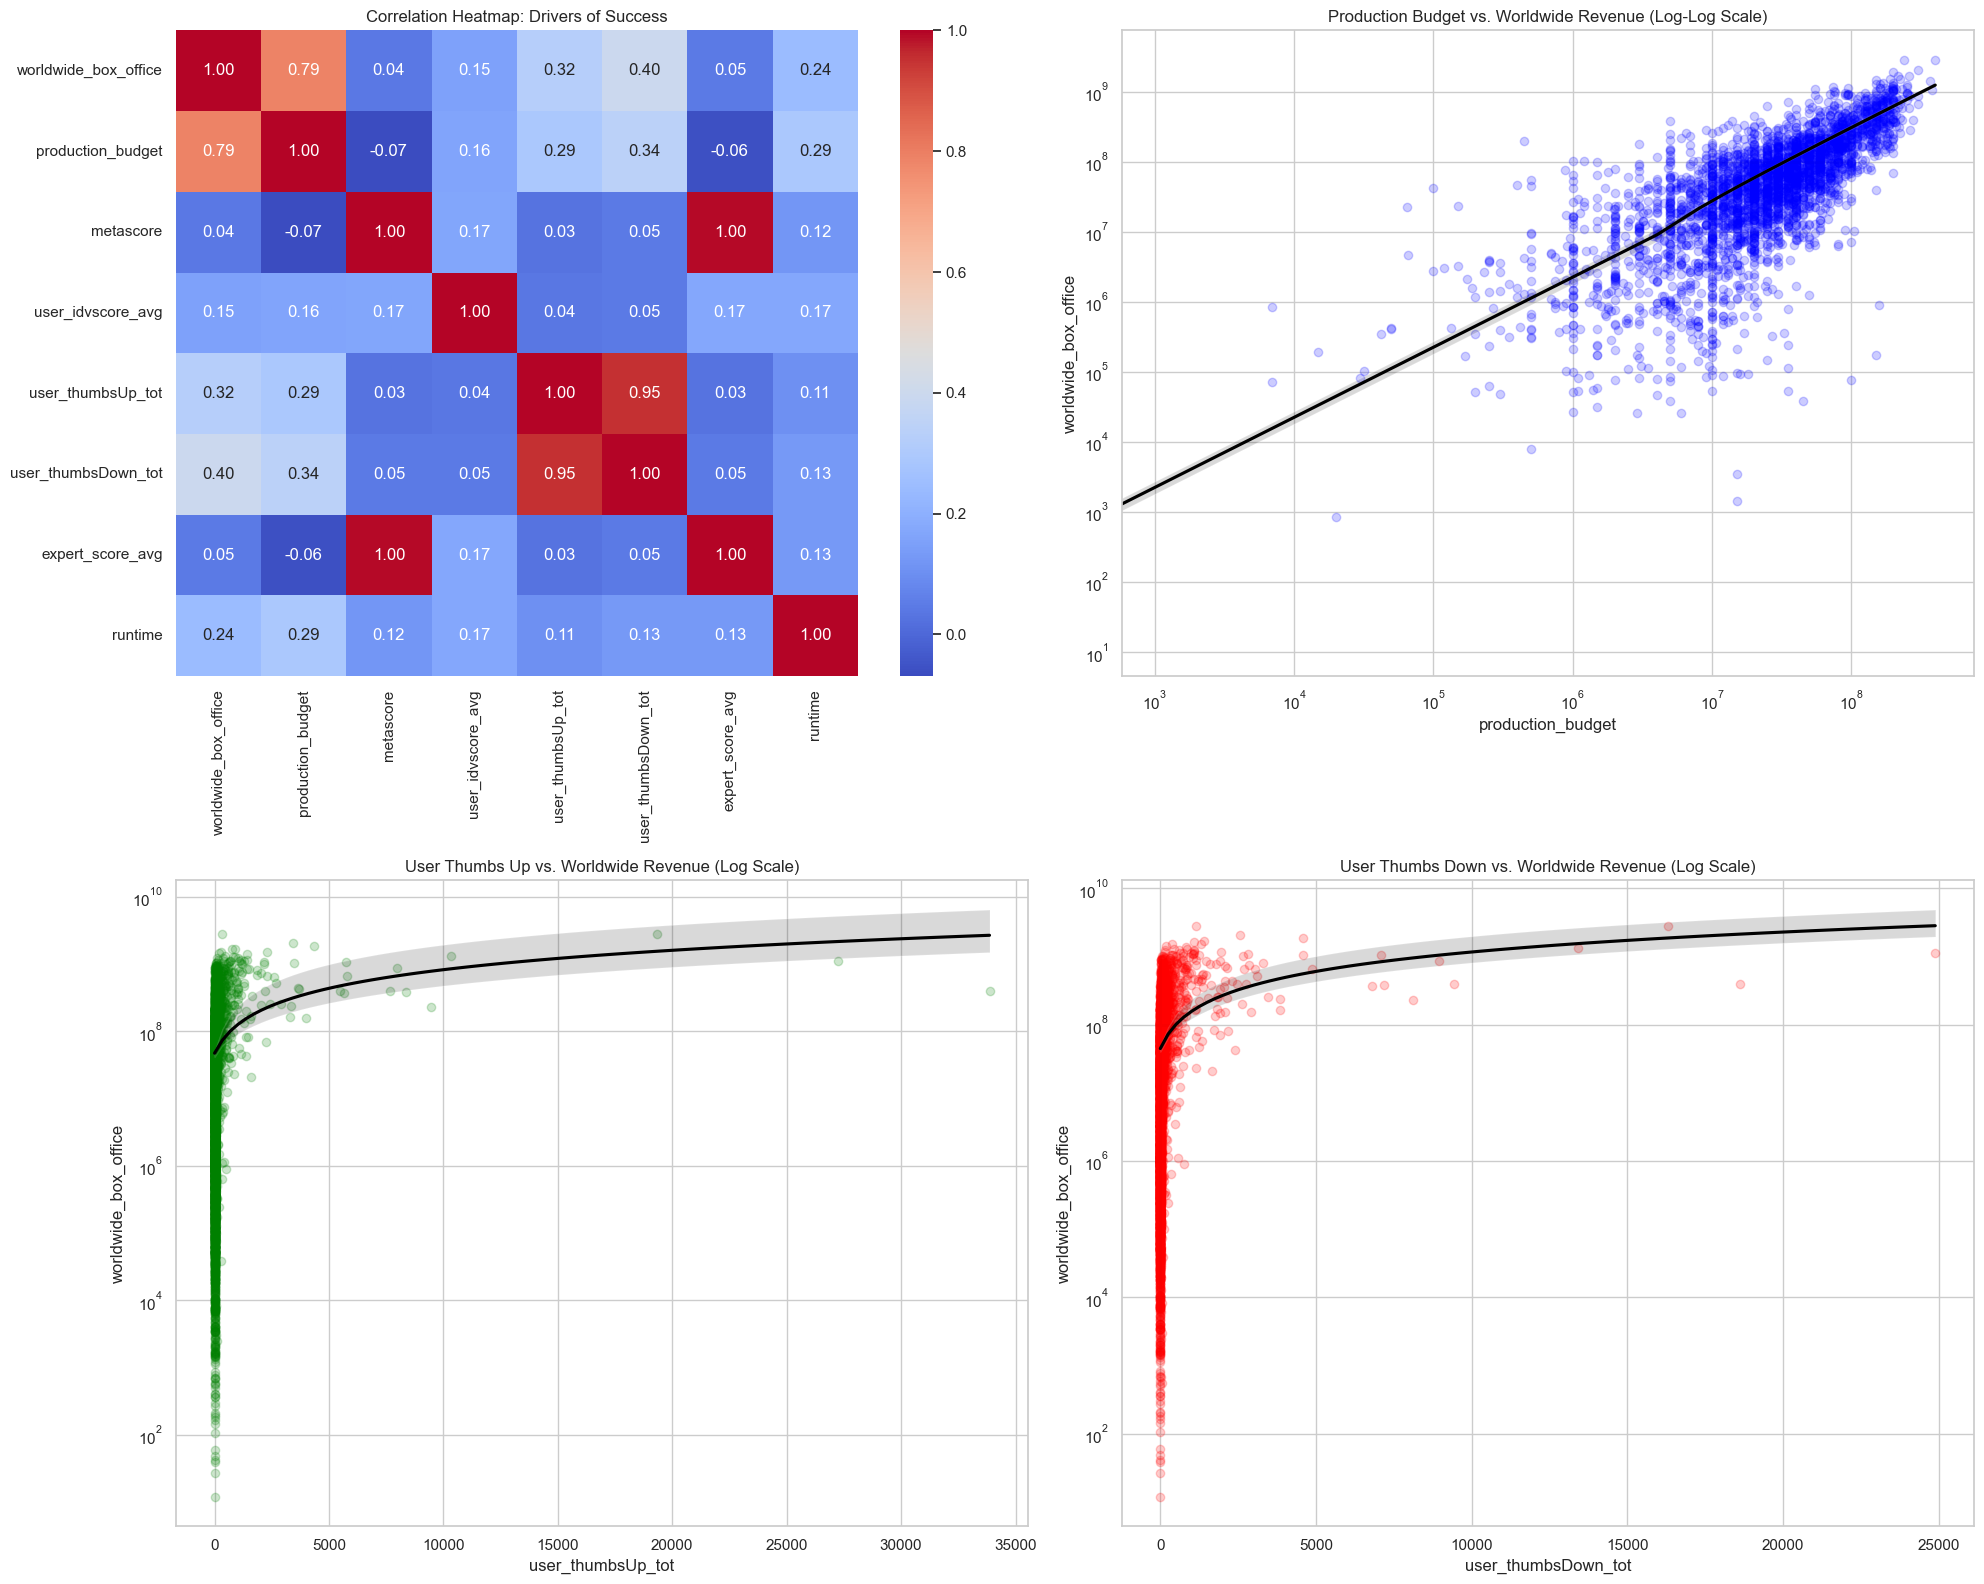

In [445]:
# Set up a 2x2 grid for a nicer visualization. Code by Muayyad 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top-Left: Correlation Heatmap
cols_to_corr = [
    'worldwide_box_office', 'production_budget', 'metascore', 
    'user_idvscore_avg', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 
    'expert_score_avg', 'runtime'
]
sns.heatmap(df_master[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0,0])
axes[0,0].set_title('Correlation Heatmap: Drivers of Success')

# Top-Right: Budget vs Revenue (Strongest Correlation: 0.79)
sns.regplot(data=df_master, x='production_budget', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'blue'}, line_kws={'color':'black'}, ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
axes[0,1].set_title('Production Budget vs. Worldwide Revenue (Log-Log Scale)')

# Bottom-Left: Thumbs Up vs Revenue
sns.regplot(data=df_master, x='user_thumbsUp_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'green'}, line_kws={'color':'black'}, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title('User Thumbs Up vs. Worldwide Revenue (Log Scale)')

# Bottom-Right: Thumbs Down vs Revenue
sns.regplot(data=df_master, x='user_thumbsDown_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'red'}, line_kws={'color':'black'}, ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('User Thumbs Down vs. Worldwide Revenue (Log Scale)')

plt.tight_layout()
plt.savefig('eda_master_grid.png')

The correlation heatmap shows that spending money on the budget is the most reliable way to predict how much money a movie will make.
Production budget has the most correlation with the world-wide-revenue.
Thumbs-up and Thumbs-down both represent engagement/audience reach, that means most successful movies get alot of hate, or love!

Since we won't use all the features for our AI models, we'll create a final dataset and we'll keep only the features that we see useful, we'll also keep only Worldwide box office as our "Y" where the value is more than "0" to train our AI model, we'll also discard international and domestic box office as we won't use those to prevent data leakage.

We'll keep the records of the unknown world wide box office for later so we can use our developed model to predict it, we'll remove them from the training data when we finish feature engineering.

In [446]:
# Define the columns we want to keep. Code by Muayyad 
features_to_keep = [
    'worldwide_box_office', 'production_budget', 'theatre_count',
    'runtime', 'metascore', 'userscore', 'expert_score_avg',
    'user_thumbsUp_tot', 'user_thumbsDown_tot', 'user_rev_count',
    'rating', 'genre', 'release_date', 'year', 'creative_type', 'movie_id', 'director',
    'expert_review_count', 'expert_positive_ratio', 'expert_sentiment_mean',
    'user_review_count', 'user_positive_ratio', 'user_sentiment_mean'
]

# Create the final modeling dataframe
df_final = df_master[features_to_keep].copy()

df_final.tail(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,...,year,creative_type,movie_id,director,expert_review_count,expert_positive_ratio,expert_sentiment_mean,user_review_count,user_positive_ratio,user_sentiment_mean
8020,55348693,50000000,3394,102.0,34,4.1,40.261905,71,54,54,...,2016,Contemporary Fiction,8021,Ben Stiller,42,0.214286,-0.566734,54,0.203704,-0.587069
8021,12506188,35000000,2501,83.0,26,4.4,30.428571,10,12,21,...,2006,Super Hero,8022,Peter Hewitt,14,0.142857,-0.704524,21,0.476190,-0.047424
8022,2784,0,0,96.0,55,5.7,56.875000,1,0,3,...,2016,Contemporary Fiction,8023,Pedro Morelli,8,0.625000,0.256527,3,1.000000,0.997055
8023,1004629935,150000000,3827,108.0,78,8.6,78.093023,1186,740,276,...,2016,Kids Fiction,8024,Byron Howard,43,0.790698,0.582791,276,0.840580,0.687389
8024,0,0,2,106.0,50,7.2,53.555556,0,0,1,...,2003,NaN,8025,Paula Van Der Oest,9,0.444444,-0.078983,1,1.000000,0.998587


In [447]:
# check file types and missing data for our final table. Code by Muayyad 
pd.concat([df_final.dtypes, df_final.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

# check length of the dataframe (how many records)
# print('original length of dataframe:', len(df_final)) # code inspired by Linear-Logistic-Regression code

,Data Type,Missing data count
worldwide_box_office,int64,0
production_budget,int64,0
theatre_count,int64,0
runtime,float64,0
metascore,int64,0
userscore,float64,0
expert_score_avg,float64,0
user_thumbsUp_tot,int64,0
user_thumbsDown_tot,int64,0
user_rev_count,int64,0


Worldwide_box_office will be our target (Y) and the others are our features (X).
We'll make some more feature engineering below:

In [448]:
# checking how many times each genre appears in the dataset, split the coma seperated genres (extracted initially from meta table). Code by Muayyad 
df1 = df_final['genre_list'] = df_final['genre'].str.split(',')
df1 = df_final.explode('genre_list') # to put seperated genres in columns

In [449]:
# Group genres to see the most frequent ones
df1.groupby('genre_list')['genre_list'].count().sort_values(ascending=False)

genre_list
Drama          4283
Comedy         2504
Thriller       1944
Documentary    1371
Romance        1277
Action         1086
Crime           972
Adventure       836
Horror          723
Mystery         630
Biography       608
Fantasy         547
Sci-Fi          532
Family          528
Music           418
History         372
Animation       277
War             270
Sport           233
Musical         128
Western          76
News             52
Short             8
Adult             7
Name: genre_list, dtype: int64

In [450]:
# We'll select the first 10 genres, because from our initial EDA we know that Adventure is the most successful genre, so it is important for the prediction. Code by Muayyad 
# Prepare the list and the Top 10 Target Genres
df_final['genre_list'] = df_final['genre'].astype(str).str.split(',')
main_genres = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 
    'Documentary', 'Adventure', 'Horror', 'Crime', 'Sci-Fi'
]

# this piece of code was enhanced with AI instead of the very long logic we used
for g in main_genres:
    # Clean the genre name for the column header (remove spaces/dashes)
    col_name = f'is_{g.lower().replace(" ", "_").replace("-", "_")}'
    
    # Check if the genre exists in the list for each row
    # .apply handles the list check; .astype(int) turns True/False into 1/0
    df_final[col_name] = df_final['genre_list'].apply(lambda x: g in [i.strip() for i in x]).astype('int64')

# Add "is_other_genre" (count of genres NOT in our top 10)
df_final['is_other_genre'] = df_final['genre_list'].apply(
    lambda x: len([i.strip() for i in x if i.strip() not in main_genres])
).astype('int64')

# Add "nr_genres" (total count of genres for that movie)
df_final['nr_genres'] = df_final['genre_list'].apply(lambda x: len(x)).astype('int64')

# Drop the temporary list column and the genre (the source column after encoding) to keep df_final clean
df_final = df_final.drop(columns=['genre_list','genre'])

print("Top 10 Genre features created successfully!")
print(df_final.filter(like='is_').head())

Top 10 Genre features created successfully!
   is_drama  is_comedy  is_thriller  is_action  is_romance  is_documentary  \
0         1          0            1          1           0               0   
1         1          1            0          0           1               0   
2         0          1            0          0           0               0   
3         1          1            0          0           1               0   
4         1          0            0          0           0               0   

   is_adventure  is_horror  is_crime  is_sci_fi  is_other_genre  
0             0          1         0          1               1  
1             0          0         0          0               0  
2             0          1         0          0               0  
3             0          0         0          0               0  
4             0          0         0          0               0  


In [451]:
# Create season map to create a new feature for the season.. Code by Muayyad 
season_map = {
    'January': 'Winter', 'February': 'Winter', 'December': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}

# Map the seasons into df_final 
# (We use .str.strip() just in case there are hidden spaces in the month names)
df_final['season'] = df_final['release_date'].str.strip().map(season_map)

# One-Hot Encode the seasons (Convert to is_summer, is_winter, etc.)
season_dummies = pd.get_dummies(df_final['season'], prefix='is_season').astype('int64')

# Join the new columns and drop the original text 'season' and 'release_date'
df_final = pd.concat([df_final, season_dummies], axis=1)
df_final = df_final.drop(columns=['season', 'release_date'])

print(df_final.filter(like='is_season').head())

   is_season_Autumn  is_season_Spring  is_season_Summer  is_season_Winter
0                 0                 1                 0                 0
1                 1                 0                 0                 0
2                 0                 0                 1                 0
3                 0                 0                 1                 0
4                 0                 1                 0                 0


In [452]:
df_final.head(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,...,is_adventure,is_horror,is_crime,is_sci_fi,is_other_genre,nr_genres,is_season_Autumn,is_season_Spring,is_season_Summer,is_season_Winter
0,108286422,15000000,3391,104.0,76,7.7,75.744186,390,535,201,...,0,1,0,1,1,6,0,1,0,0
1,987640,0,3,100.0,61,6.9,62.666667,1,1,7,...,0,0,0,0,0,3,1,0,0,0
2,0,0,13,91.0,63,7.5,65.800000,0,0,2,...,0,1,0,0,0,2,0,0,1,0
3,20452,0,0,99.0,75,7.4,75.166667,0,0,2,...,0,0,0,0,0,3,0,0,1,0
4,47019,0,0,93.0,65,0.0,67.000000,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [453]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   worldwide_box_office   8025 non-null   int64   
 1   production_budget      8025 non-null   int64   
 2   theatre_count          8025 non-null   int64   
 3   runtime                8025 non-null   float64 
 4   metascore              8025 non-null   int64   
 5   userscore              8025 non-null   float64 
 6   expert_score_avg       8025 non-null   float64 
 7   user_thumbsUp_tot      8025 non-null   int64   
 8   user_thumbsDown_tot    8025 non-null   int64   
 9   user_rev_count         8025 non-null   int64   
 10  rating                 8025 non-null   category
 11  year                   8025 non-null   int32   
 12  creative_type          7369 non-null   category
 13  movie_id               8025 non-null   int64   
 14  director               8025 non-null   o

In [454]:
# check Nan values vs "0" in Runtime to impute
nan_count = df_final['runtime'].isna().sum()
zero_count = (df_final['runtime'] == 0).sum()

print(f"Number of Nan values: {nan_count}")
print(f"Number of 0.0 runtimes: {zero_count}")

Number of Nan values: 0
Number of 0.0 runtimes: 164


In [455]:


# Flag the rows that are missing runtime so we can look at them later. Code by Muayyad 
missing_mask = (df_final['runtime'] == 0) | (df_final['runtime'].isna())

# Convert the 0.0 values to NaN for the imputer
df_final['runtime'] = df_final['runtime'].replace(0, np.nan)

# Select columns to take into consideration # code enhanced with AI instead of the manual naming of the previously encoded columns
impute_cols = ['runtime', 'production_budget'] + [col for col in df_final.columns if 'is_' in col]

# Initialize and run the Imputer, we'll check the nearest 3 neighbours
imputer = KNNImputer(n_neighbors=3)
df_temp = pd.DataFrame(imputer.fit_transform(df_final[impute_cols]), columns=impute_cols)

# We create a small table showing the "Before" (which was 0/NaN) and the "After"
verification_df = pd.DataFrame({
    'Old_Runtime': 0, # this was changed to 0 earlier when we were changing data types
    'Imputed_Runtime': df_temp.loc[missing_mask, 'runtime'].values
})

print("Check the imputation")
print(verification_df.head(10)) 
# This lets you see if the numbers look realistic (for example, 90, 105, 120)




Check the imputation
   Old_Runtime  Imputed_Runtime
0            0        93.000000
1            0        82.000000
2            0        87.333333
3            0       108.000000
4            0       116.666667
5            0       116.000000
6            0       101.333333
7            0        85.000000
8            0       108.000000
9            0        91.000000


In [456]:
# The numbers actually look realistic. Code by Muayyad 
# Put the verified runtimes back into df_final
df_final['runtime'] = df_temp['runtime'].values

# Final cleanup: round to whole minutes
df_final['runtime'] = df_final['runtime'].round(0).astype('int64')

del df_temp

print("Final check number of zeros =", (df_final['runtime'] == 0).sum())

Final check number of zeros = 0


# Preparing for modelling

we'll create a new table called df_final_clean that has values greater than 0 for world wide box office, and move the ones that has 0 values to another dataframe to predict them later

In [457]:
df_ready = df_final.copy()

In [458]:
# --------------------------------------------------
# STEP 2: Target variable
# --------------------------------------------------

y = df_ready['worldwide_box_office']

print("Target min:", y.min())
print("Target max:", y.max())
print("Target missing values:", y.isna().sum())

Target min: 0
Target max: 2845899541
Target missing values: 0


In [459]:
# ==============================
# CLEAN RATING
# ==============================

rating_map = {
    'Not Rated': 'Unrated',
    'NR': 'Unrated',
    'TV-MA': 'R',
    'TV-14': 'PG-13',
    'TV-G': 'G',
    'TV-PG': 'PG'
}

df_ready['rating'] = (
    df_ready['rating']
    .replace(rating_map)
    .fillna('Unrated')
)

print("Rating distribution after cleaning:")
print(df_ready['rating'].value_counts())
print("-" * 50)

Rating distribution after cleaning:
rating
R           2938
Unrated     2529
PG-13       1746
PG           670
G             99
NC-17         31
Open           4
PG--13         4
Approved       2
M/PG           1
MA-17          1
Name: count, dtype: int64
--------------------------------------------------


In [460]:
# ==============================
# IMPUTE CREATIVE TYPE
# ==============================

# Safe categorical imputation (MODE)
df_ready['creative_type'] = (
    df_ready['creative_type']
    .fillna(df_ready['creative_type'].mode()[0])
)

print("Creative type missing values after imputation:",
      df_ready['creative_type'].isna().sum())
print("-" * 50)


Creative type missing values after imputation: 0
--------------------------------------------------


In [461]:
# ==============================
# FIX DIRECTOR
# Convert director identity → experience signal
# ==============================

# Count how many movies each director has
director_counts = df_ready['director'].value_counts()

# Map experience buckets
df_ready['director_bucket'] = df_ready['director'].map(
    lambda x:
        'new_director' if director_counts.get(x, 0) == 1 else
        'low_exp' if director_counts.get(x, 0) <= 3 else
        'mid_exp' if director_counts.get(x, 0) <= 10 else
        'high_exp'
)

# Drop high-cardinality original column
df_ready = df_ready.drop(columns=['director'])

print("Director experience buckets:")
print(df_ready['director_bucket'].value_counts())
print("-" * 50)




Director experience buckets:
director_bucket
new_director    3087
low_exp         2436
mid_exp         2241
high_exp         261
Name: count, dtype: int64
--------------------------------------------------


In [462]:
# ==============================
# ONE-HOT ENCODING
# ==============================

df_ready = pd.get_dummies(
    df_ready,
    columns=['rating', 'creative_type', 'director_bucket'],
    drop_first=True
)

print("Encoding complete.")
print("Final shape:", df_ready.shape)
print("-" * 50)

# ==============================
# FINAL SANITY CHECK
# ==============================

print("Dtype summary:")
print(df_ready.dtypes.value_counts())


print("STEP 3 COMPLETED — DATA IS CLEAN & MODEL-READY")

Encoding complete.
Final shape: (8025, 55)
--------------------------------------------------
Dtype summary:
int64      27
bool       21
float64     6
int32       1
Name: count, dtype: int64
STEP 3 COMPLETED — DATA IS CLEAN & MODEL-READY


In [463]:
# --------------------------------------------------
# Drop identifier
# --------------------------------------------------

df_ready = df_ready.drop(columns=['movie_id'])

In [464]:
# --------------------------------------------------
#  Feature / target split
# --------------------------------------------------

X = df_ready.drop(columns=['worldwide_box_office'])
y = df_ready['worldwide_box_office']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8025, 53)
y shape: (8025,)


In [465]:
# --------------------------------------------------
# Convert boolean columns to 0/1
# --------------------------------------------------

bool_cols = df_ready.select_dtypes(include='bool').columns
df_ready[bool_cols] = df_ready[bool_cols].astype(int)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Converted {len(bool_cols)} boolean columns to int.")

print("Boolean columns converted in df_final.")

Converted 21 boolean columns to int.
Boolean columns converted in df_final.


In [466]:
# --------------------------------------------------
# Final checks
# --------------------------------------------------
#
print(X.dtypes.value_counts())
print("Total missing values:", X.isna().sum().sum())

assert X.isna().sum().sum() == 0, "Missing values still exist!"
assert len(X.select_dtypes(exclude=[np.number]).columns) == 0, \
    "Non-numeric columns remain!"

print("FINAL CHECK PASSED — DATA IS MODEL-READY")

int64      25
int32      22
float64     6
Name: count, dtype: int64
Total missing values: 0
FINAL CHECK PASSED — DATA IS MODEL-READY


In [467]:
# Now, I want to remove the movies that have 0 world wide box office and move them to another table. Code by Muayyad 
# Create a table with only movies that have a box office greater than 0
df_final_clean = df_ready[df_ready['worldwide_box_office'] > 0].copy()

# Move the rows with 0 box office to a separate "Zero Box Office" table
df_zero_box_office = df_ready[df_ready['worldwide_box_office'] == 0].copy()

# Verification
print(f"Movies with valid Box Office data: {df_final_clean.shape[0]}")
print(f"Movies moved to the Zero Table: {df_zero_box_office.shape[0]}")

# Check the minimum value in our new clean table to be sure
print(f"New minimum Box Office: ${df_final_clean['worldwide_box_office'].min()}")

Movies with valid Box Office data: 5081
Movies moved to the Zero Table: 2944
New minimum Box Office: $12


In [468]:
# --------------------------------------------------
# Save datasets
# --------------------------------------------------

import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

# Training data
df_final_clean.to_csv(
    os.path.join(output_dir, "final_modeling_dataset.csv"),
    index=False
)

# Prediction data
df_zero_box_office.to_csv(
    os.path.join(output_dir, "zero_box_office_dataset.csv"),
    index=False
)

# Full master backup
df_master.to_csv(
    os.path.join(output_dir, "master_merged_dataset.csv"),
    index=False
)

print("FILES SAVED SUCCESSFULLY")
print("Final modeling dataset:", df_final_clean.shape)
print("Zero box office dataset:", df_zero_box_office.shape)
print("Master dataset:", df_master.shape)


FILES SAVED SUCCESSFULLY
Final modeling dataset: (5081, 54)
Zero box office dataset: (2944, 54)
Master dataset: (8025, 1577)
